In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()

✨🍰✨ Everything looks OK!


In [ ]:
!conda create -n flowmae python=3.8.13 -y

Channels:
 - conda-forge
Platform: linux-64
Solving environment: - \ done


==> WARNING: A newer version of conda exists. <==
    current version: 24.11.2
    latest version: 26.5.2

Please update conda by running

    $ conda update -n base -c conda-forge conda



## Package Plan ##

  environment location: /usr/local/envs/flowmae

  added / updated specs:
    - python=3.8.13


The following NEW packages will be INSTALLED:

  _openmp_mutex      conda-forge/linux-64::_openmp_mutex-4.5-20_gnu 
  bzip2              conda-forge/linux-64::bzip2-1.0.8-hda65f42_9 
  ca-certificates    conda-forge/noarch::ca-certificates-2026.5.20-hbd8a1cb_0 
  ld_impl_linux-64   conda-forge/linux-64::ld_impl_linux-64-2.45.1-default_hbd61a6d_102 
  libffi             conda-forge/linux-64::libffi-3.4.6-h2dba641_1 
  libgcc             conda-forge/linux-64::libgcc-15.2.0-he0feb66_19 
  libgcc-ng          conda-forge/linux-64::libgcc-ng-15.2.0-h69a702a_19 
  libgomp            conda-forge/linux-64::libgomp-1

In [ ]:
!source activate flowmae && \
pip install torch==1.12.1+cu116 torchvision==0.13.1+cu116 --extra-index-url https://download.pytorch.org/whl/cu116 && \
pip install \
  numpy==1.21.5 \
  transformers==4.24.0 \
  tqdm==4.65.0 \
  datasets==2.12.0 \
  fsspec==2022.11.0 \
  pandas==2.0.3 \
  scikit-learn==1.0.2 \
  evaluate==0.4.0 \
  click==8.0.4 \
  dpkt==1.9.8 \
  psutil==5.9.0 \
  pyspark==3.3.2 \
  scapy==2.4.3 \
  pyarrow==8.0.0

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu116
  Using cached https://download-r2.pytorch.org/whl/cu116/torch-1.12.1%2Bcu116-cp38-cp38-linux_x86_64.whl (1904.8 MB)
  Using cached https://download-r2.pytorch.org/whl/cu116/torchvision-0.13.1%2Bcu116-cp38-cp38-linux_x86_64.whl (23.5 MB)
  Using cached https://download.pytorch.org/whl/typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached numpy-1.24.4-cp38-cp38-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.6 kB)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached pillow-10.4.0-cp38-cp38-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached charset_normalizer-3.4.7-cp38-cp38-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl.metadata (40 kB)
  Using cached idna-3.15-py3-none-any.whl.metadata (7.7 kB)
  Using cached urllib3-2.2.3-py3-none-any.whl.metadata (6.5 kB)
  Using cached certifi-2026.5.20-py3-none-any.whl.metadata

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!git clone https://github.com/NLear/Flow-MAE.git

Cloning into 'Flow-MAE'...
remote: Enumerating objects: 96, done.
remote: Counting objects: 100% (96/96), done.
remote: Compressing objects: 100% (83/83), done.
remote: Total 96 (delta 10), reused 96 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (96/96), 2.41 MiB | 2.42 MiB/s, done.
Resolving deltas: 100% (10/10), done.


In [ ]:
%cd /content/Flow-MAE

/content/Flow-MAE


In [ ]:
import pickle
import numpy as np
import os
import random
import gc
from collections import defaultdict

def sanitize_and_flatten(obj):
    """NumPy 배열 제거 및 순수 리스트 구조로 완벽 변환"""
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return [sanitize_and_flatten(v) for v in obj.values()]
    elif isinstance(obj, (list, tuple)):
        return [sanitize_and_flatten(v) for v in obj]
    return obj

# 1. 경로 설정
base_path = "/content/drive/MyDrive/ISCX-VPN-APP"
input_path = f"{base_path}/ISCX.pkl"

train_output_path = f"{base_path}/train.pkl"
val_output_path = f"{base_path}/val.pkl"

print(f"📂 1. 원본 통합 데이터 로딩 중: {os.path.basename(input_path)}")
if not os.path.exists(input_path):
    print(f"❌ 에러: {input_path} 경로에 파일이 없습니다.")
else:
    with open(input_path, "rb") as f:
        data = pickle.load(f)

    # 2. 데이터 안전 추출
    valid_data = []
    for row in data:
        if isinstance(row, dict):
            pcap_item = row.get('layers_layerData')
            if pcap_item is None:
                pcap_item = row.get('tcp.payload')

            label_item = row.get('label')

            if pcap_item is not None and label_item is not None and label_item != 'label':
                valid_data.append([pcap_item, label_item])
        elif isinstance(row, (list, tuple)) and len(row) >= 2:
            if row[1] != 'label':
                valid_data.append([row[0], row[1]])

    del data
    gc.collect()

    unique_labels = sorted(list(set([row[1] for row in valid_data])))
    label_map = {name: i for i, name in enumerate(unique_labels)}

    print("\n🎯 [ISCX 클래스 매핑 결과]")
    for name, idx in label_map.items():
        print(f" - {name.ljust(20)} : {idx}")
    print(f"✅ 총 클래스 개수: {len(label_map)}개\n")

    grouped_data = defaultdict(list)
    for pcap, label_str in valid_data:
        grouped_data[label_str].append(pcap)

    del valid_data
    gc.collect()

    # 클래스 불균형 해결
    # 특정 클래스가 너무 많은 것을 방지하기 위한 최대치 캡(Cap) 설정
    MAX_SAMPLES_PER_CLASS = 1000

    print(f"2. 데이터 균형 조절 및 8:2 정밀 분할 중... (클래스당 최대 {MAX_SAMPLES_PER_CLASS}개 제한)")

    train_data = []
    val_data = []

    for label_str, items in grouped_data.items():
        label_idx = label_map[label_str]

        random.shuffle(items)
        sampled_items = items[:MAX_SAMPLES_PER_CLASS]

        split_idx = max(1, int(len(sampled_items) * 0.8)) if len(sampled_items) > 1 else 1

        class_train = sampled_items[:split_idx]
        class_val = sampled_items[split_idx:]

        for pcap in class_train:
            pcap_clean = sanitize_and_flatten(pcap)
            train_data.append([pcap_clean, len(pcap_clean), label_idx])

        for pcap in class_val:
            pcap_clean = sanitize_and_flatten(pcap)
            val_data.append([pcap_clean, len(pcap_clean), label_idx])

    del grouped_data
    gc.collect()

    random.shuffle(train_data)
    random.shuffle(val_data)

    print(f"\n💾 3. 구글 드라이브에 최종 파일 저장 중...")

    with open(train_output_path, "wb") as f:
        pickle.dump(train_data, f)
    print(f"   ✅ {os.path.basename(train_output_path)} 저장 완료! (학습 데이터: {len(train_data):,}개)")

    with open(val_output_path, "wb") as f:
        pickle.dump(val_data, f)
    print(f"   ✅ {os.path.basename(val_output_path)} 저장 완료! (검증 데이터: {len(val_data):,}개)")

    print(f"\n🎉 '균형 층화 데이터셋' 생성이 완료되었습니다!")

📂 1. 원본 통합 데이터 로딩 중: ISCX.pkl

🎯 [ISCX 클래스 매핑 결과]
 - AIMchat1             : 0
 - AIMchat2             : 1
 - aim_chat_3a          : 2
 - aim_chat_3b          : 3
 - email1a              : 4
 - email1b              : 5
 - email2a              : 6
 - email2b              : 7
 - facebook_audio1a     : 8
 - facebook_audio1b     : 9
 - facebook_audio2a     : 10
 - facebook_audio2b     : 11
 - facebook_audio3      : 12
 - facebook_audio4      : 13
 - facebook_chat_4a     : 14
 - facebook_chat_4b     : 15
 - facebook_video1a     : 16
 - facebook_video1b     : 17
 - facebook_video2a     : 18
 - facebook_video2b     : 19
 - facebookchat1        : 20
 - facebookchat2        : 21
 - facebookchat3        : 22
 - vpn_aim_chat1a       : 23
 - vpn_aim_chat1b       : 24
 - vpn_bittorrent       : 25
 - vpn_email2a          : 26
 - vpn_email2b          : 27
 - vpn_facebook_audio2  : 28
 - vpn_facebook_chat1a  : 29
 - vpn_facebook_chat1b  : 30
 - vpn_ftps_A           : 31
 - vpn_ftps_B           : 32
 - 

In [ ]:
import pickle
import os

base_path = "/content/drive/MyDrive/ISCX-VPN-APP"
train_file = f"{base_path}/train.pkl"
val_file = f"{base_path}/val.pkl"

def deep_flatten(lst):
    """2차원 이상으로 꼬인 리스트를 1차원으로 Flat"""
    flat = []
    for item in lst:
        if isinstance(item, (list, tuple)):
            flat.extend(deep_flatten(item))
        else:
            flat.append(item)
    return flat

def fix_and_rescue_dataset(file_path):
    print(f"데이터 복구 시작: {os.path.basename(file_path)}")
    with open(file_path, "rb") as f:
        data = pickle.load(f)

    # 1. 흩어진 정답(Label) 번호들을 0, 1, 2... 순서대로 다시 매핑
    unique_labels = sorted(list(set(row[2] for row in data)))
    label_map = {old_lbl: new_idx for new_idx, old_lbl in enumerate(unique_labels)}

    fixed_data = []
    for packet, length, label in data:
        # 1-1. 2차원 리스트를 1024개의 1차원 리스트로 평탄화
        flat_packet = deep_flatten(packet)

        # 1-2. 0~1 소수점을 0~255 정수(Byte)로 원상 복구! (시력 회복)
        denorm_packet = [int(min(max(v * 255.0, 0), 255)) if v <= 1.0 else int(v) for v in flat_packet]

        # 1-3. 진짜 패킷 길이 계산 (0이 아닌 마지막 데이터의 위치 찾기)
        last_idx = 0
        for i, val in enumerate(denorm_packet):
            if val != 0:
                last_idx = i
        true_length = max(last_idx + 1, 1)

        # 1-4. 정답 번호 재배치
        new_label = label_map[label]

        fixed_data.append([denorm_packet, true_length, new_label])

    # 기존 파일을 덮어쓰지 않고 '_fixed.pkl' 이라는 새 이름으로 저장합니다.
    new_file_path = file_path.replace(".pkl", "_fixed.pkl")
    with open(new_file_path, "wb") as f:
        pickle.dump(fixed_data, f)

    print(f"   ✅ 복구 완료 -> {os.path.basename(new_file_path)} 저장됨!")
    print(f"   (총 클래스 개수: {len(label_map)}개)\n")
    return len(label_map)

# 훈련용, 검증용 데이터 모두 수술 진행
num_labels_train = fix_and_rescue_dataset(train_file)
num_labels_val = fix_and_rescue_dataset(val_file)

print(f"🎉 모든 수술이 끝났습니다! 최종 모델 클래스 개수(--num_labels)는 {num_labels_train} 입니다.")

🛠️ 복구 시작: train.pkl
   ✅ 복구 완료 -> train_fixed.pkl 저장됨!
   (총 클래스 개수: 54개)

🛠️ 복구 시작: val.pkl
   ✅ 복구 완료 -> val_fixed.pkl 저장됨!
   (총 클래스 개수: 54개)

🎉 모든 수술이 끝났습니다! 최종 모델 클래스 개수(--num_labels)는 54 입니다.


In [ ]:
# USTC-TFC2016 데이터셋으로 사전학습 완료한 모델을 ISCX-VPN-APP 데이터셋으로 파인튜닝

dataset_name = "ISCX-VPN-APP"
train_file = "/content/drive/MyDrive/ISCX-VPN-APP/train_fixed_core.pkl"
val_file = "/content/drive/MyDrive/ISCX-VPN-APP/val_fixed_core.pkl"
output_dir = "/content/drive/MyDrive/ISCX-finetuning-core"
model_path = "/content/drive/MyDrive/USTC-TFC2016-pretraining/ustc_20epoch_pretrained_model"
script_path = "/content/Flow-MAE/finetune.py"

!source activate flowmae && torchrun \
  --nnodes=1 \
  --nproc_per_node=1 \
  {script_path} \
  --dataset_name {dataset_name} \
  --train_dir {train_file} \
  --validation_dir {val_file} \
  --output_dir {output_dir} \
  --overwrite_output_dir \
  --model_name_or_path {model_path} \
  --return_entity_level_metrics True \
  --remove_unused_columns False \
  --num_channels 1 \
  --num_attention_heads 4 \
  --num_labels 34 \
  --hidden_dropout_prob 0.1 \
  --attention_probs_dropout_prob 0.1 \
  --mask_ratio 0 \
  --image_column_name "tcp.payload" \
  --norm_pix_loss \
  --do_train \
  --do_eval \
  --base_learning_rate 1e-3 \
  --lr_scheduler_type "cosine" \
  --weight_decay 0.08 \
  --num_train_epochs 30 \
  --warmup_ratio 0.1 \
  --per_device_train_batch_size 32 \
  --per_device_eval_batch_size 32 \
  --dataloader_num_workers 0 \
  --logging_strategy steps \
  --logging_steps 50 \
  --evaluation_strategy "epoch" \
  --save_strategy "epoch" \
  --load_best_model_at_end True \
  --metric_for_best_model "eval_f1" \
  --greater_is_better True \
  --save_total_limit 3 \
  --seed 1337

[2026/06/14 07:57-INFO-distributed_c10d.py(228)] >> Added key: store_based_barrier_key:1 to store for rank: 0
[2026/06/14 07:57-INFO-distributed_c10d.py(262)] >> Rank 0: Completed store-based barrier for key:store_based_barrier_key:1 with 1 nodes.
[2026/06/14 07:57-WARNING-finetune.py(172)] >> Process rank: 0, device: cuda:0, n_gpu: 1distributed training: True, 16-bits training: False
[2026/06/14 07:57-INFO-finetune.py(176)] >> Training/evaluation parameters CustomTrainingArguments(
_n_gpu=1,
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
base_learning_rate=0.001,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_pin_memory=True,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=True,
eval_accumulation_steps=None,
eval_delay=0,
eval_steps=None,
evaluation_strat

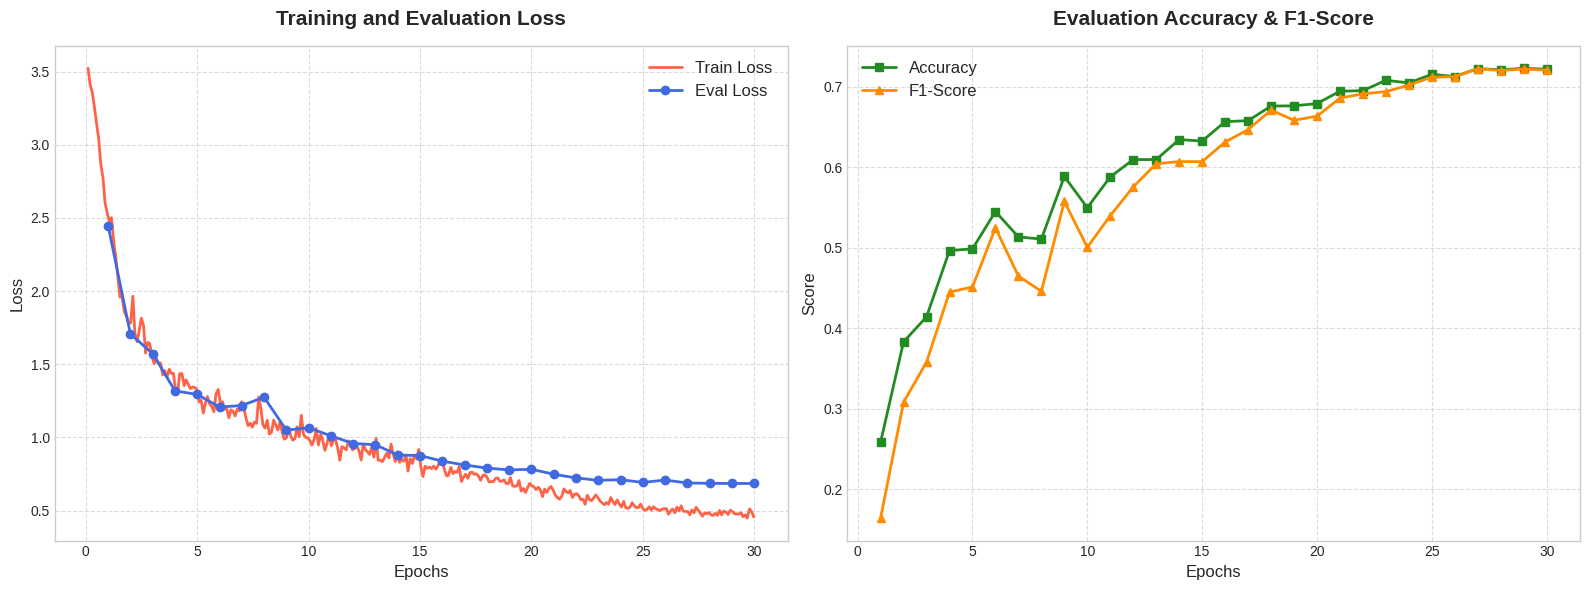

In [ ]:
import json
import matplotlib.pyplot as plt
import os

# 1. 학습 기록 파일 경로 설정
# 학습이 끝나면 메인 출력 폴더에 최종 trainer_state.json이 저장됨
state_file = "/content/drive/MyDrive/ISCX-finetuning-core/trainer_state.json"

if not os.path.exists(state_file):
    print(f"❌ 파일을 찾을 수 없습니다: {state_file}")
    print("가장 숫자가 큰 checkpoint-OOOO 폴더 안의 trainer_state.json 경로로 수정해 주세요.")
else:
    # 2. JSON 파일 읽어오기
    with open(state_file, "r") as f:
        state = json.load(f)

    log_history = state["log_history"]

    # 3. 그래프를 그릴 빈 리스트 준비
    train_epochs, train_loss = [], []
    eval_epochs, eval_loss, eval_acc, eval_f1 = [], [], [], []

    # 4. 로그 데이터 분류해서 담기
    for log in log_history:
        # 학습(Train) 로그일 경우
        if "loss" in log and "eval_loss" not in log:
            train_epochs.append(log["epoch"])
            train_loss.append(log["loss"])
        # 평가(Eval) 로그일 경우
        elif "eval_loss" in log:
            eval_epochs.append(log["epoch"])
            eval_loss.append(log["eval_loss"])
            eval_acc.append(log["eval_accuracy_score"])
            eval_f1.append(log["eval_f1"])

    # 5. 시각화 (Matplotlib) 그리기
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # [그래프 1] Training vs Evaluation Loss
    ax1.plot(train_epochs, train_loss, label="Train Loss", color='tomato', linewidth=2)
    ax1.plot(eval_epochs, eval_loss, label="Eval Loss", marker='o', color='royalblue', linewidth=2)
    ax1.set_title("Training and Evaluation Loss", fontsize=15, fontweight='bold', pad=15)
    ax1.set_xlabel("Epochs", fontsize=12)
    ax1.set_ylabel("Loss", fontsize=12)
    ax1.legend(fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.7)

    # [그래프 2] Evaluation Accuracy & F1-Score
    ax2.plot(eval_epochs, eval_acc, label="Accuracy", marker='s', color='forestgreen', linewidth=2)
    ax2.plot(eval_epochs, eval_f1, label="F1-Score", marker='^', color='darkorange', linewidth=2)
    ax2.set_title("Evaluation Accuracy & F1-Score", fontsize=15, fontweight='bold', pad=15)
    ax2.set_xlabel("Epochs", fontsize=12)
    ax2.set_ylabel("Score", fontsize=12)
    ax2.legend(fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

In [ ]:
import pickle
import os
from collections import Counter

base_path = "/content/drive/MyDrive/ISCX-VPN-APP"
train_file = f"{base_path}/train_fixed.pkl"
val_file = f"{base_path}/val_fixed.pkl"

def drop_minority_classes_and_repack(train_path, val_path, min_samples=100):
    print("🧹 [데이터 다이어트 시작] 소수 클래스 제거 및 핵심 클래스 재정렬\n")

    with open(train_path, "rb") as f:
        train_data = pickle.load(f)
    with open(val_path, "rb") as f:
        val_data = pickle.load(f)

    # 1. 훈련 데이터 기준으로 각 클래스(Label)의 데이터 개수 세기
    label_counts = Counter([row[2] for row in train_data])

    # 2. 데이터 개수가 min_samples(50개) 이상인 '생존 클래스'만 선별
    surviving_labels = sorted([label for label, count in label_counts.items() if count >= min_samples])

    print(f"📊 전체 클래스 수: {len(label_counts)}개")
    print(f"🔥 생존 핵심 클래스 수: {len(surviving_labels)}개 (기준: 훈련 데이터 {min_samples}개 이상)")
    print(f"🗑️ 버려지는 소수 클래스 수: {len(label_counts) - len(surviving_labels)}개\n")

    # 3. 생존한 클래스들에게 0번부터 새로운 정답 번호(ID) 부여
    new_label_map = {old_label: new_id for new_id, old_label in enumerate(surviving_labels)}

    # 4. 데이터 필터링 및 번호 덮어쓰기
    new_train_data = []
    for packet, length, label in train_data:
        if label in new_label_map:
            new_train_data.append([packet, length, new_label_map[label]])

    new_val_data = []
    for packet, length, label in val_data:
        if label in new_label_map:
            new_val_data.append([packet, length, new_label_map[label]])

    # 5. 새로운 파일로 저장
    new_train_path = train_path.replace(".pkl", "_core.pkl")
    new_val_path = val_path.replace(".pkl", "_core.pkl")

    with open(new_train_path, "wb") as f:
        pickle.dump(new_train_data, f)
    with open(new_val_path, "wb") as f:
        pickle.dump(new_val_data, f)

    print(f"✅ 압축 완료!")
    print(f"   - 훈련 데이터: {len(train_data)}개 -> {len(new_train_data)}개")
    print(f"   - 검증 데이터: {len(val_data)}개 -> {len(new_val_data)}개")
    print(f"   - 최종 모델 클래스 개수(--num_labels): {len(surviving_labels)}")
    print(f"\n💾 저장된 파일: {os.path.basename(new_train_path)}, {os.path.basename(new_val_path)}")

    return len(surviving_labels)

# 커트라인을 50개로 설정하여 데이터 다이어트 실행!
final_num_labels = drop_minority_classes_and_repack(train_file, val_file, min_samples=100)

🧹 [데이터 다이어트 시작] 소수 클래스 제거 및 핵심 클래스 재정렬

📊 전체 클래스 수: 54개
🔥 생존 핵심 클래스 수: 34개 (기준: 훈련 데이터 100개 이상)
🗑️ 버려지는 소수 클래스 수: 20개

✅ 압축 완료!
   - 훈련 데이터: 17569개 -> 16690개
   - 검증 데이터: 4410개 -> 4181개
   - 최종 모델 클래스 개수(--num_labels): 34

💾 저장된 파일: train_fixed_core.pkl, val_fixed_core.pkl
